# Bubble method comparison (GSADF vs LPPLS vs CUSUM)

This notebook runs the same logic as **`bubble_method_comparison.py`** by calling **`run_comparison()`**.
The `.py` file remains the single source of truth for helpers and the CLI (`python bubble_method_comparison.py`).

**Inputs** (under repo `R/` or `R/data_R/`): prefer `df_master_gsadf.csv`, `df_master_lppls.csv`, `df_master_cusum.csv`.

**Outputs:** by default **`metals/outputs/`** (repository root, same folder level as `R/` and `notebooks/`): `bubble_methods_*.csv` and PNGs — Jaccard heatmap, three-row raster (day index), and **`bubble_methods_overlap_timeline.png`** (three bar tracks per metal: GSADF / LPPLS / CUSUM, same colours per method). If you used an older version of this script, figures may instead be under **`Metals/outputs/`** (one level *above* the `metals` repo folder); check `result["paths"]` after running for exact paths.

## 1. Load the comparison module

Works whether the Jupyter **working directory** is the **metals** repo root or **`notebooks/analysis`**.

In [12]:
import importlib.util
import sys
from pathlib import Path

_candidates = []
for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents[:6]]:
    _candidates.extend(
        [
            base / "notebooks" / "analysis" / "bubble_method_comparison.py",
            base / "bubble_method_comparison.py",
        ]
    )

_mod_path = next((p for p in _candidates if p.is_file()), None)
if _mod_path is None:
    raise FileNotFoundError(
        "bubble_method_comparison.py not found. Open the notebook from the metals repo or cd to notebooks/analysis."
    )

_spec = importlib.util.spec_from_file_location("bubble_method_comparison", _mod_path)
bmc = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(bmc)
# Required for importlib.reload() on some Python versions (e.g. 3.14)
sys.modules[_spec.name] = bmc
print("Loaded:", _mod_path)

Loaded: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\notebooks\analysis\bubble_method_comparison.py


## 2. Run comparison

- Set **`RECOMPUTE_CUSUM = True`** to ignore `df_master_cusum.csv` and recompute CUSUM from the GSADF master (slower).
- Set **`OUTPUT_DIR`** to a string path to override the default `outputs/` folder.

In [13]:
import importlib
import sys

# Pick up edits to bubble_method_comparison.py without restarting the kernel
_mod_name = getattr(bmc, "__name__", "bubble_method_comparison")
if sys.modules.get(_mod_name) is not bmc:
    sys.modules[_mod_name] = bmc
importlib.reload(sys.modules[_mod_name])

RECOMPUTE_CUSUM = False
OUTPUT_DIR = ""  # e.g. r"C:\temp\bubble_out" or leave "" for repo outputs/

result = bmc.run_comparison(
    recompute_cusum=RECOMPUTE_CUSUM,
    output_dir=OUTPUT_DIR or None,
)

Aligned panel: 2152 rows, 2017-05-10 — 2025-10-31
GSADF master: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\df_master_gsadf.csv
LPPLS master: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\df_master_lppls.csv
CUSUM source: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\R\df_master_cusum.csv
Wrote C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\outputs\bubble_methods_prevalence.csv
Wrote C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\outputs\bubble_methods_pairwise_metrics.csv
Wrote C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\outputs\bubble_methods_cohen_kappa.csv

Cobalt — count of methods flagging bubble (0..3):
0    1943
1     163
2      41
3       5

Copper — count of methods flagging bubble

## 3. Inspect results and figures

Tables below, then **saved PNGs** embedded from `result["paths"]` (so you see the latest overlap plot in the notebook).

Output directory: C:\Users\user\OneDrive - Uniwersytet Ekonomiczny w Poznaniu\Dokumenty\Publikacje\Metals\metals\outputs
Files: {'prevalence_csv': WindowsPath('C:/Users/user/OneDrive - Uniwersytet Ekonomiczny w Poznaniu/Dokumenty/Publikacje/Metals/metals/outputs/bubble_methods_prevalence.csv'), 'pairwise_csv': WindowsPath('C:/Users/user/OneDrive - Uniwersytet Ekonomiczny w Poznaniu/Dokumenty/Publikacje/Metals/metals/outputs/bubble_methods_pairwise_metrics.csv'), 'heatmap_png': WindowsPath('C:/Users/user/OneDrive - Uniwersytet Ekonomiczny w Poznaniu/Dokumenty/Publikacje/Metals/metals/outputs/bubble_methods_jaccard_heatmap.png'), 'raster_png': WindowsPath('C:/Users/user/OneDrive - Uniwersytet Ekonomiczny w Poznaniu/Dokumenty/Publikacje/Metals/metals/outputs/bubble_methods_timeline_raster.png'), 'overlap_timeline_png': WindowsPath('C:/Users/user/OneDrive - Uniwersytet Ekonomiczny w Poznaniu/Dokumenty/Publikacje/Metals/metals/outputs/bubble_methods_overlap_timeline.png')}


,metal,method,bubble_days,pct
0,Cobalt,GSADF,135,6.273234
1,Cobalt,LPPLS,14,0.650558
2,Cobalt,CUSUM,111,5.157993
3,Copper,GSADF,24,1.115242
4,Copper,LPPLS,25,1.161710
5,Copper,CUSUM,194,9.014870
6,Lithium,GSADF,466,21.654275
7,Lithium,LPPLS,13,0.604089
8,Lithium,CUSUM,220,10.223048
9,Nickel,GSADF,11,0.511152


,metal,pair,jaccard,precision_vs_gsadf,recall_vs_gsadf
0,Cobalt,gsadf–lppls,0.034722,NaN,NaN
1,Cobalt,gsadf–cusum,0.177033,NaN,NaN
2,Cobalt,lppls–cusum,0.126126,NaN,NaN
3,Cobalt,LPPLS_vs_GSADF_PR,NaN,0.357143,0.037037
4,Cobalt,CUSUM_vs_GSADF_PR,NaN,0.333333,0.274074
5,Copper,gsadf–lppls,0.065217,NaN,NaN
6,Copper,gsadf–cusum,0.101010,NaN,NaN
7,Copper,lppls–cusum,0.063107,NaN,NaN
8,Copper,LPPLS_vs_GSADF_PR,NaN,0.120000,0.125000
9,Copper,CUSUM_vs_GSADF_PR,NaN,0.103093,0.833333


,metal,pair,cohen_kappa
0,Cobalt,gsadf–lppls,0.055985
1,Cobalt,gsadf–cusum,0.258855
2,Cobalt,lppls–cusum,0.214929
3,Copper,gsadf–lppls,0.112347
4,Copper,gsadf–cusum,0.166951
5,Copper,lppls–cusum,0.100202
6,Lithium,gsadf–lppls,0.043032
7,Lithium,gsadf–cusum,0.404118
8,Lithium,lppls–cusum,0.101336
9,Nickel,gsadf–lppls,-0.006639


**Jaccard heatmap**

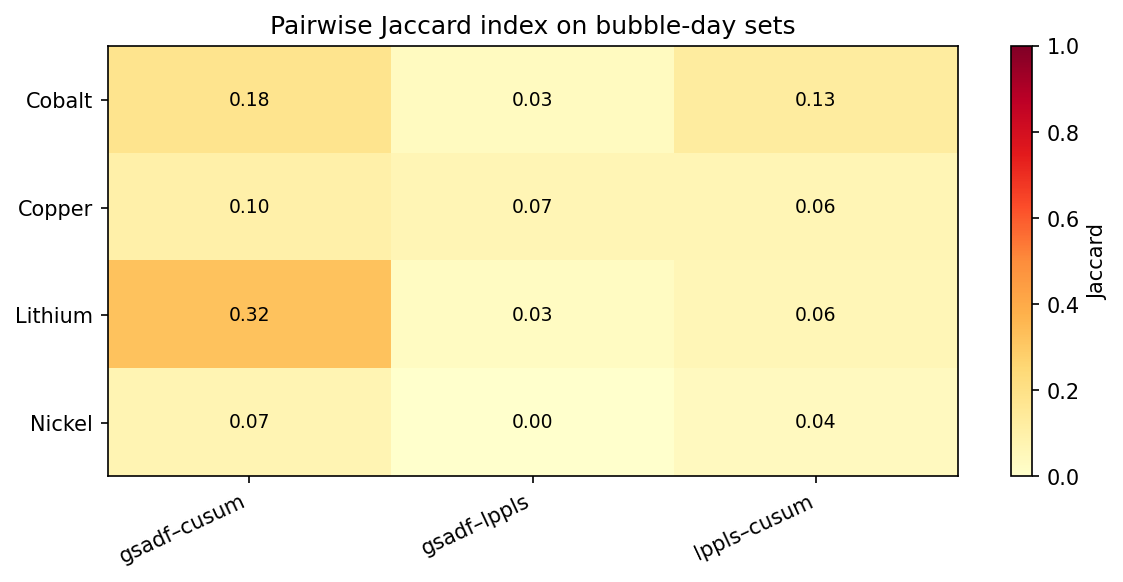

**Timeline raster (day index)**

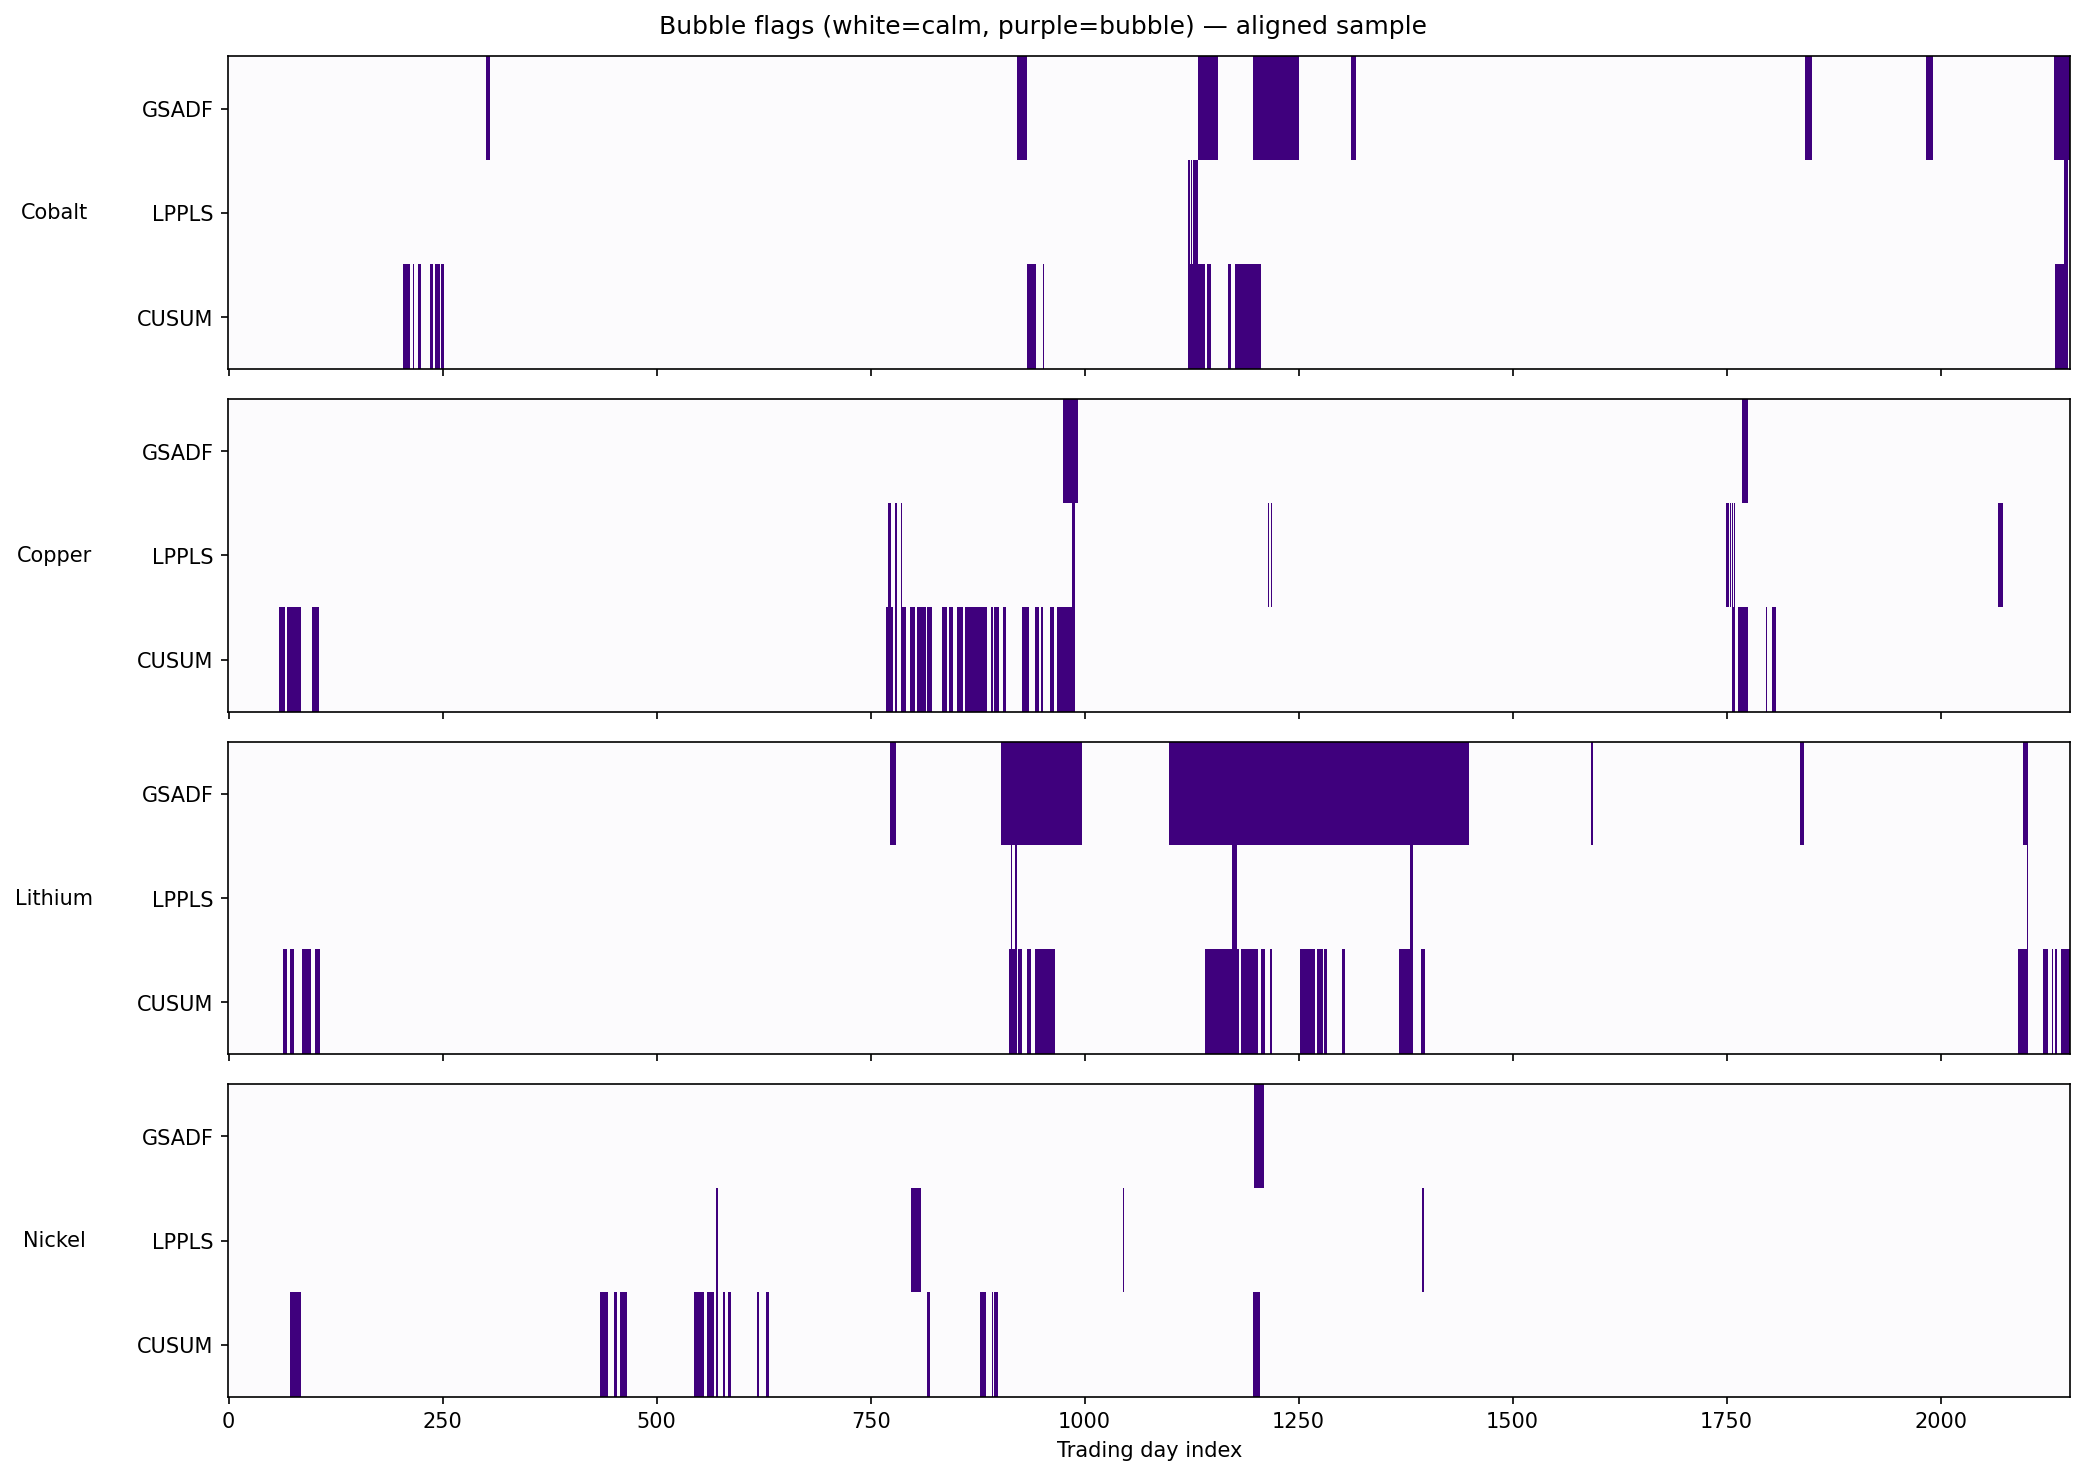

**Overlap timeline (three bar rows per metal)**

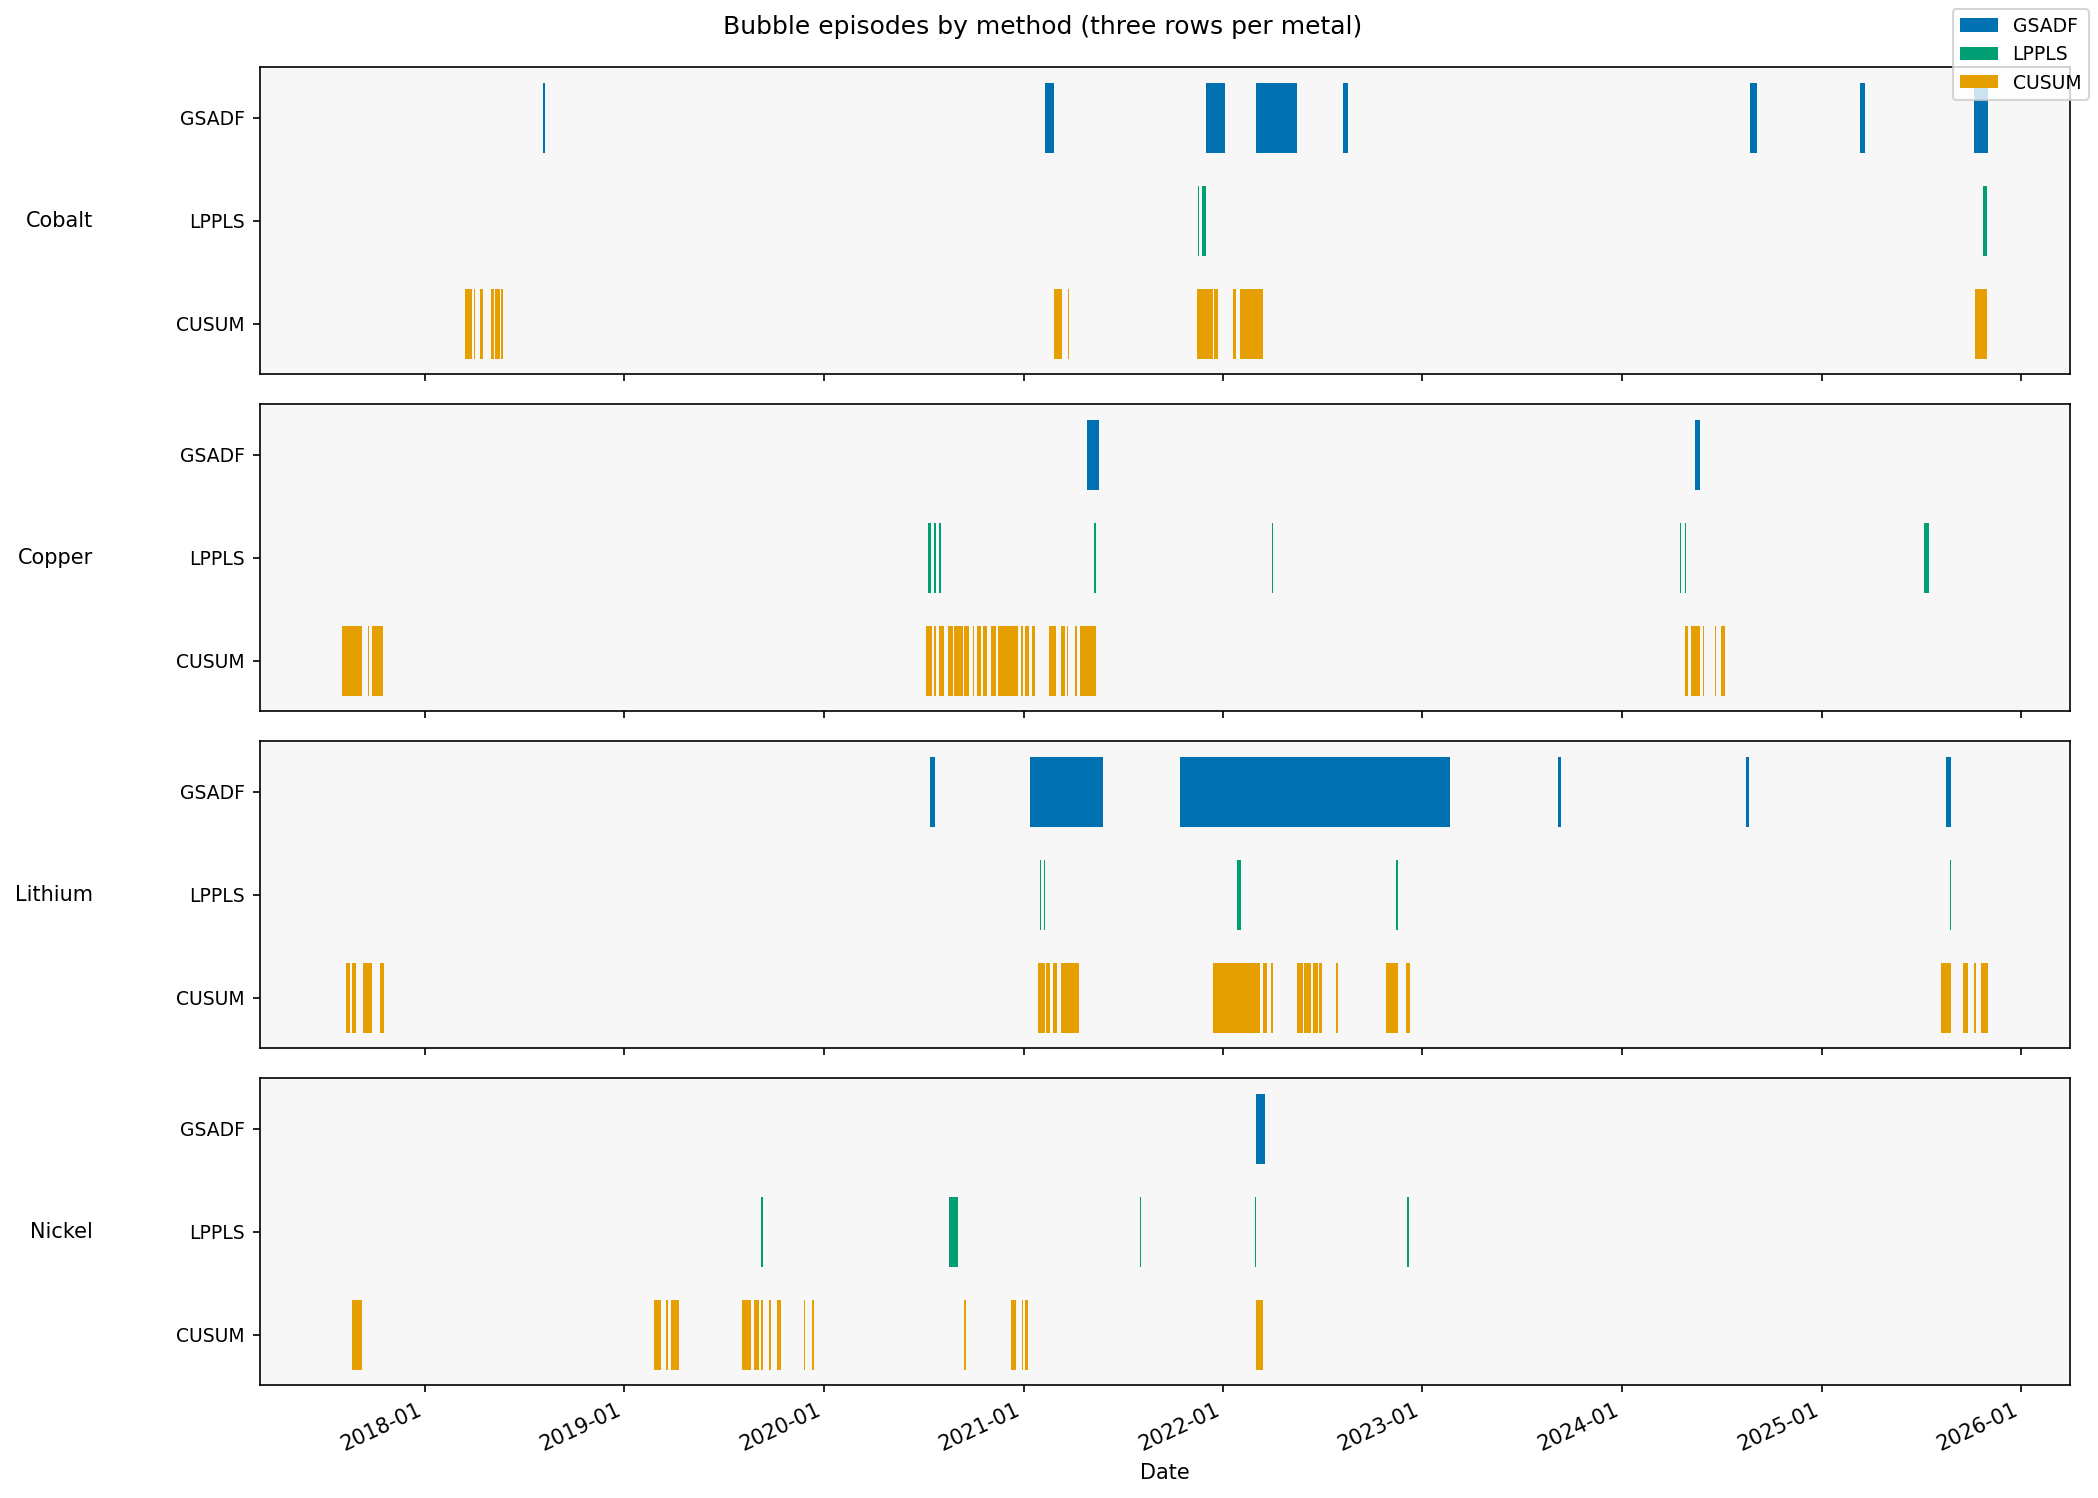

In [14]:
from IPython.display import Image, Markdown, display

print("Output directory:", result["out_dir"])
print("Files:", result["paths"])
display(result["prevalence"])
display(result["pairwise"].head(20))
if result["kappa"] is not None:
    display(result["kappa"])
else:
    print("(Install scikit-learn for Cohen kappa table)")

for title, key in [
    ("Jaccard heatmap", "heatmap_png"),
    ("Timeline raster (day index)", "raster_png"),
    ("Overlap timeline (three bar rows per metal)", "overlap_timeline_png"),
]:
    p = result["paths"][key]
    display(Markdown(f"**{title}**"))
    display(Image(filename=str(p), width=960))